# Tarefa - Python para ciência de dados
Autor : Rhenan de Sousa Gonçalves

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
df = pd.read_csv("../../data/vendas_brasil_1.csv")
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## Entregável 1

### Item A

In [ ]:
#checando as colunas nu'merias do dataframe 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [10]:
# catando os array numpy
p_unit = df['preco_unitario'].values
c_unit = df['custo_unitario'].values
qtdd = df['quantidade'].values
desc = df['desconto_pct'].values
rec_tot = df['receita_total'].values
frete = df['frete'].values
#sempre bom conferir
print(type(p_unit))

<class 'numpy.ndarray'>


## Item B

### Valor bruto de venda

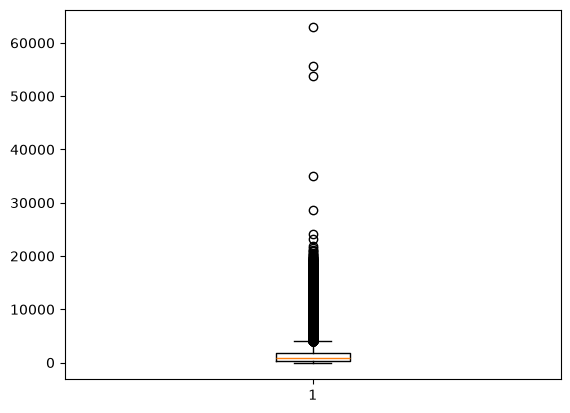

In [ ]:
val_bruto = p_unit * qtdd
plt.boxplot(val_bruto)
plt.show()
## ta com pouco outlier na criança

In [44]:
m =np.mean(val_bruto)
sd = np.std(val_bruto)
len(np.where(val_bruto>m+3*sd)[0])/len(val_bruto)
#nah ssó 2%

0.02934843288938512

### Valor do desconto

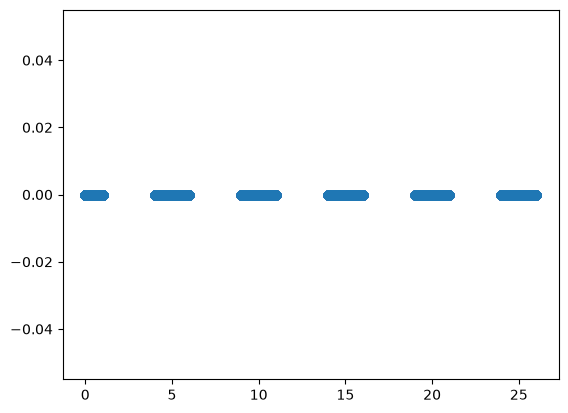

In [ ]:
plt.scatter(x=desc, y=np.zeros_like(desc))

In [32]:
k = desc[np.logical_and(desc<1,desc>0)]
len(k)/len(desc)

0.17085360342398384

A coluna de desconto é bem suspeita: ela é percentual. Tem muitos valores entre 0 e 1, quase 20% dos dados. Desconto de 0.5% nao faz 
muito sentido, aparenta ser o valor percentual normalizado. enquanto o resto esta com o valor absoluto. Na duvida vou assumir que todos são absolutos, ms imagino que os pequenos sejam um erro de entrada de dados.

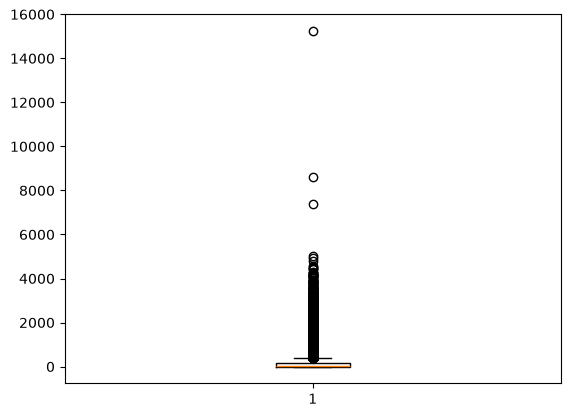

In [ ]:
val_desconto = v_bruto * desc/100
plt.boxplot(val_desconto)
plt.show()

## msm skew da anterior

### Custo Total

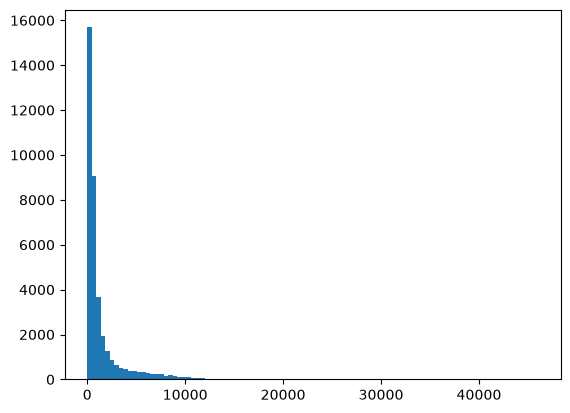

In [52]:
c_total = c_unit * qtdd
#variar o plot
plt.hist(c_total, bins = 100)
plt.show()

### Lucro Estimado

In [69]:
lucro = val_bruto - desc  - c_total 
print(np.mean(lucro))
print(np.median(lucro))

512.9067591780312
205.51999999999998


## Item C

### receita acima da media

In [ ]:
med = np.mean(rec_tot)
acima_da_media = rec_tot[rec_tot > med]
len(rec_tot)/len(acima_da_media)

#media altissima dnv, por conta dos outliers bizarros, mediada aqui seria mais robusto

4.072867042009528

### Vendas com prejuízo

In [76]:
preju = lucro[lucro<0]
print("porcentagem das vendas no negativo")
print(len(preju)/len(lucro))

porcentagem das vendas no negativo
0.016269239971289578


### Desconto alto

In [77]:
## defini q desconto alto é acima de 25% pq sim
desc_alto = desc[desc>25]
len(desc_alto)/len(desc)

0.06124890342132547

## Item D

### REceita Média

In [79]:
np.mean(rec_tot)

np.float64(1891.6881729005502)

## maior receita

In [80]:
np.max(rec_tot)

np.float64(58430.28)

## menor receita


In [81]:
np.min(rec_tot)

np.float64(3.7)

## lucro medio

In [82]:
np.mean(lucro)

np.float64(512.9067591780312)

## qntdd de prejuizo

In [87]:
len(preju)

612

## Conclusão

A empresa tá indo bem, tem poucas vendas no prejuizo e no geral ela ta lucrando bem (desconsiderando custos operacionais). As vendas tem um perfil especifico, onde alguns poucos itens tem valores muito altos e a maioria cai mais abaixo.